# 03: Baum-Welch (EM) — Learning HMM Parameters from Data

## Goals
1. Initialize HMM parameters randomly (not using the true values)
2. Implement the full EM loop: E step (forward-backward → γ, ξ) then M step (update π, A, μ, σ²)
3. Run until convergence (monitor log-likelihood)
4. Verify: learned parameters should converge close to the true values used to generate the data
5. Verify: regime assignments from learned model should match true hidden states

## Setup
- Same synthetic data from notebook 01 (N=500, same seed)
- Parameters initialized randomly — EM must recover them
- M step updates follow Bishop equations 13.18–13.21

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

In [2]:
# True parameters (for data generation and final comparision)
pi = np.array([0.8, 0.2]) # (80% chance of starting in calm)
A = np.array([[0.95, 0.05], [0.1, 0.9]]) # (Calm remains 95% of the time, crisis does so 90%)
mu = np.array([0.05, -0.2]) # (Calm has a small positive mean, crisis has negative mean)
sigma_squared = np.array([1.0, 4.0]) # (Crisis has much higher variance)
latent_state = 0 # (0 indexing all states)

In [3]:
def sample_hmm(pi, A, mu, sigma_squared, N):
    states = np.zeros(N, dtype=int)
    observations = np.zeros(N)

    # Sample z_1 from pi
    states[0] = np.random.choice([0,1], p=pi)
    observations[0] = np.random.normal(loc=mu[states[0]], scale=np.sqrt(sigma_squared[states[0]]))

    for n in range (1, N):
        states[n] = np.random.choice([0,1], p=A[states[n-1]])
        observations[n] = np.random.normal(loc=mu[states[n]], scale=np.sqrt(sigma_squared[states[n]]))

    return states, observations

In [4]:
N = 500
states, observations = sample_hmm(pi, A, mu, sigma_squared, N)

In [22]:
# Forward pass function for alpha returning array of shape (N, 2)
def forward_pass(observations, pi, A, mu, sigma_squared):
    N = len(observations)
    alpha = np.zeros((N, 2))
    log_likelihood = 0.0
    
    # alpha initialization:
    # initial state probability * emission density
    for k in range(2):
        alpha[0,k] = pi[k] * norm.pdf(observations[0], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
    c = alpha[0, :].sum()
    alpha[0, :] /= c
    log_likelihood += np.log(c)
        
    for n in range(1, N):
        for k in range(2):
            # emission probability of x_n under state k, multiplied by 
            # the sum over all previous states j
            alpha[n,k] = norm.pdf(observations[n], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
            previous_states = 0
            for j in range(2):
                previous_states += alpha[n-1, j] * A[j, k]
            alpha[n, k] *= previous_states
        # Underflow protection
        c =  alpha[n, :].sum()
        alpha[n, :] /= c
        log_likelihood += np.log(c)
        
    return alpha, log_likelihood

In [23]:
# Returning shape (N, 2)
def backward_pass(observations, pi, A, mu, sigma_squared):
    N = len(observations)
    beta = np.zeros((N, 2))

    # Beta initialization
    # beta(z_{Nk})=1
    for k in range(2):
        beta[N - 1, k] = 1

    for n in range(N-2, -1, -1):
        for k in range(2):
            for j in range(2):
                # For each future state j, emission probability of x_{n+1} under state j times transition from k to j times
                # the sum over all future states j
                beta[n, k] += A[k, j] * norm.pdf(observations[n+1], loc=mu[j], scale=np.sqrt(sigma_squared[j])) * beta[n+1, j]

        # Underflow protection
        beta[n, :] /= beta[n, :].sum()

    return beta

### New parameter initialization begins here

In [24]:
pi_est = np.random.dirichlet([1,1])
A_est = np.array([np.random.dirichlet([1, 1]) for _ in range(2)])
mu_est = np.random.randn(2)
sigma_sq_est = np.abs(np.random.randn(2)) + 0.5

In [27]:
def EM_step(observations, pi, A, mu, sigma_squared):
    N = len(observations)

    # === E Step ===
    alpha, log_likelihood = forward_pass(observations, pi, A, mu, sigma_squared)
    beta = backward_pass(observations, pi, A, mu, sigma_squared)
    
    # Gamma is alpha[n, k] * beta[n, k] normalized so the two states sum to 1
    gamma = alpha * beta
    gamma = gamma / gamma.sum(axis=1, keepdims=True)

    # Set up xi
    xi = np.zeros((N - 1, 2, 2))
    for n in range(1, N):
        for j in range(2):
            for k in range(2):
                xi[n - 1, j, k] = (alpha[n-1, j] 
                                   * A[j, k]
                                   * norm.pdf(observations[n], loc=mu[k], scale=np.sqrt(sigma_squared[k]))
                                   * beta[n, k])
        # Normalize so all four entries sum to 1
        xi[n - 1] /= xi[n-1].sum()

    # === M Step ===
    # pi_k = gamma(z_{1k})
    pi_new = gamma[0]

    # A_{jk} = sum_n xi(j,k) / sum_n sum_l xi(j,l)
    A_new = np.zeros((2,2))
    for j in range(2):
        for k in range(2):
            A_new[j,k] = xi[:, j, k].sum() / xi[:, j, :].sum()

    # mu_k = sum_n gamma(z_{nk}) * x_n / sum_n gamma(z_{nk})
    mu_new = np.zeros(2)
    for k in range(2):
        mu_new[k] = np.sum(gamma[:, k] * observations) / np.sum(gamma[:, k])

    # sigma_k^2 = sum_n gamma(z_{nk} * (x_n - mu_k)^2) / sum_n gamma(z_{nk})
    sigma_sq_new = np.zeros(2)
    for k in range(2):
        sigma_sq_new[k] = np.sum(gamma[:, k] * (observations - mu_new[k])**2) / np.sum(gamma[:, k])

    return pi_new, A_new, mu_new, sigma_sq_new, log_likelihood

In [28]:
# E + M loop
prev_log_likelihood = -np.inf
for i in range(100):
    pi_est, A_est, mu_est, sigma_sq_est, log_likelihood = EM_step(observations, pi_est, A_est, mu_est, sigma_sq_est)
    if i % 10 == 0:
        print(f"Iteration {i}: log-likelihood = {log_likelihood:.4f}")
    if abs(log_likelihood - prev_log_likelihood) < 1e-6:
        print(f"Converged at iteration {i}")
        break
    prev_log_likelihood = log_likelihood


Iteration 0: log-likelihood = -950.5257
Iteration 10: log-likelihood = -842.2702
Iteration 20: log-likelihood = -840.4401
Iteration 30: log-likelihood = -840.0175
Iteration 40: log-likelihood = -839.9978
Iteration 50: log-likelihood = -839.9975
Converged at iteration 52


In [31]:
print("Parameter comparison (true → learned):")
print(f"pi:       {pi} → {pi_est}")
print(f"A row 0:  {A[0]} → {A_est[0]}")
print(f"A row 1:  {A[1]} → {A_est[1]}")
print(f"mu:       {mu} → {mu_est}")
print(f"sigma_sq: {sigma_squared} → {sigma_sq_est}")

Parameter comparison (true → learned):
pi:       [0.8 0.2] → [1.0000000e+00 8.2825426e-34]
A row 0:  [0.95 0.05] → [0.97865578 0.02134422]
A row 1:  [0.1 0.9] → [0.06809509 0.93190491]
mu:       [ 0.05 -0.2 ] → [ 0.06510318 -0.20586493]
sigma_sq: [1. 4.] → [1.19856091 3.89365708]


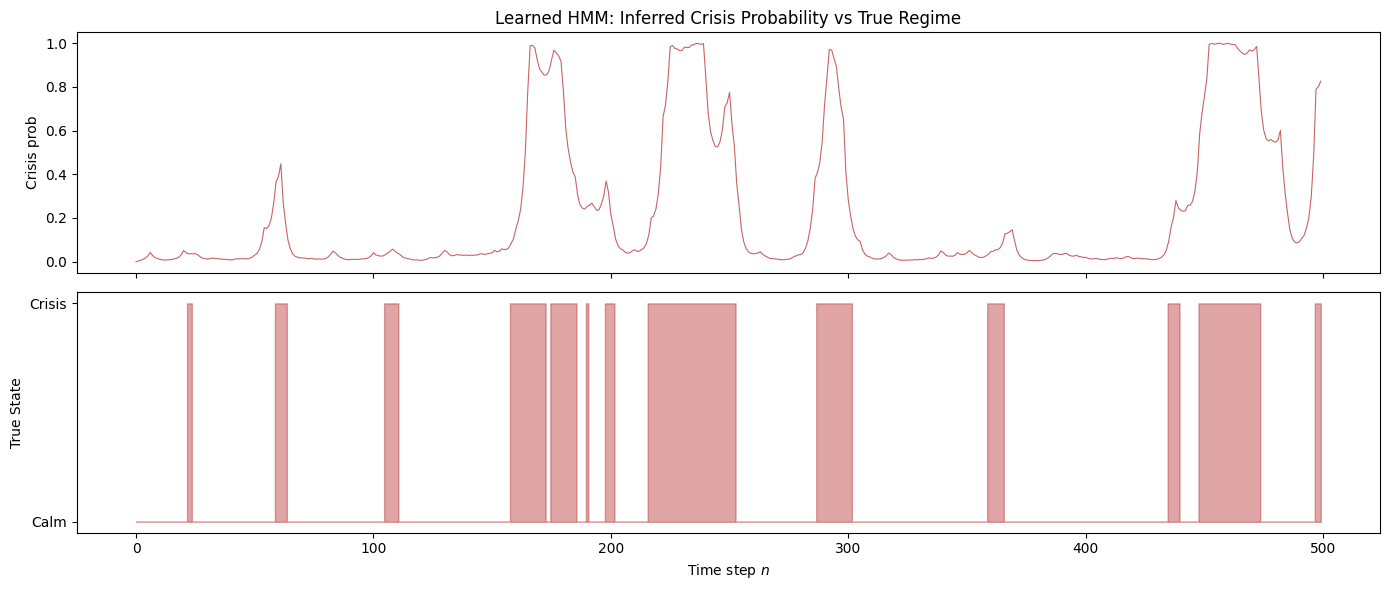

In [32]:
alpha_final, _ = forward_pass(observations, pi_est, A_est, mu_est, sigma_sq_est)
beta_final = backward_pass(observations, pi_est, A_est, mu_est, sigma_sq_est)
gamma_final = alpha_final * beta_final
gamma_final = gamma_final / gamma_final.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(gamma_final[:, 1], color='firebrick', alpha=0.7, linewidth=0.8)
ax1.set_ylabel('Crisis prob')
ax1.set_title('Learned HMM: Inferred Crisis Probability vs True Regime')

ax2.fill_between(range(N), states, alpha=0.4, color='firebrick', step='mid')
ax2.set_ylabel('True State')
ax2.set_xlabel('Time step $n$')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Calm', 'Crisis'])

plt.tight_layout()
plt.show()